# Profitly — Exploratory Data Analysis

This notebook explores the dataset that backs Profitly's ML services: ~90 days
of per-video, per-day YouTube analytics for one creator (50 videos). It loads a
CSV export (`data/`) so it runs without any database access.

The goal is to *characterise the structure* the downstream models have to
exploit: weekly seasonality, content-category economics, and a mid-series
audience-mix shift that drags revenue down.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True, "grid.alpha": 0.25})
ACCENT, INK = "#b8530e", "#1a1712"

DATA = Path.cwd() / "data"
daily = pd.read_csv(DATA / "daily_analytics.csv", parse_dates=["date"])
videos = pd.read_csv(DATA / "videos.csv")
daily = daily.merge(videos[["id", "category"]], left_on="video_id", right_on="id", how="left")
print(f"{len(daily):,} daily rows | {videos.shape[0]} videos | "
      f"{daily.date.min().date()} → {daily.date.max().date()}")
videos.category.value_counts()

3,943 daily rows | 50 videos | 2026-02-28 → 2026-05-28


category
vlog        18
tutorial    14
shorts       9
other        5
review       4
Name: count, dtype: int64

## 1. Channel revenue over time

Aggregating to channel-level daily revenue. Two things to look for: a **weekly
wobble** (weekday vs weekend) and a **downward shift around day 60** — that's a
planted audience-mix change we'll detect later in the anomaly notebook.

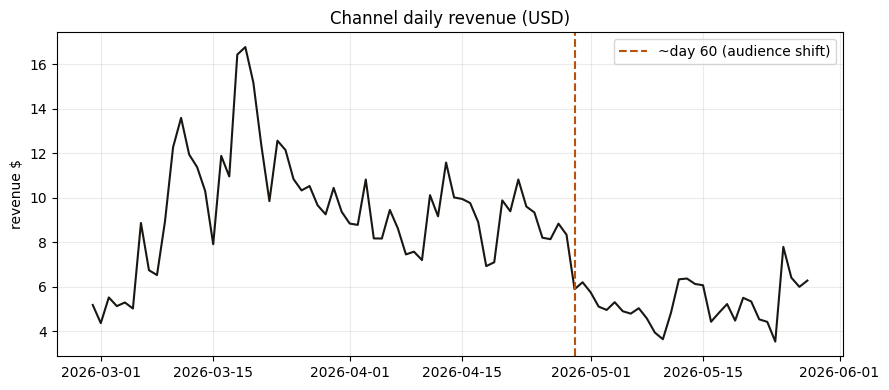

In [2]:
ch = daily.groupby("date").agg(revenue=("revenue_usd", "sum"),
                               views=("views", "sum")).reset_index()
fig, ax = plt.subplots()
ax.plot(ch.date, ch.revenue, color=INK, lw=1.5)
ax.axvline(ch.date.iloc[60], color=ACCENT, ls="--", lw=1.5, label="~day 60 (audience shift)")
ax.set(title="Channel daily revenue (USD)", ylabel="revenue $", xlabel="")
ax.legend()
plt.tight_layout(); plt.show()

## 2. Weekly seasonality

Mean revenue by weekday. A clear weekday lift is exactly the signal a seasonal
forecaster (Holt-Winters ETS) is built to capture — and why a plain "last value"
baseline leaves accuracy on the table.

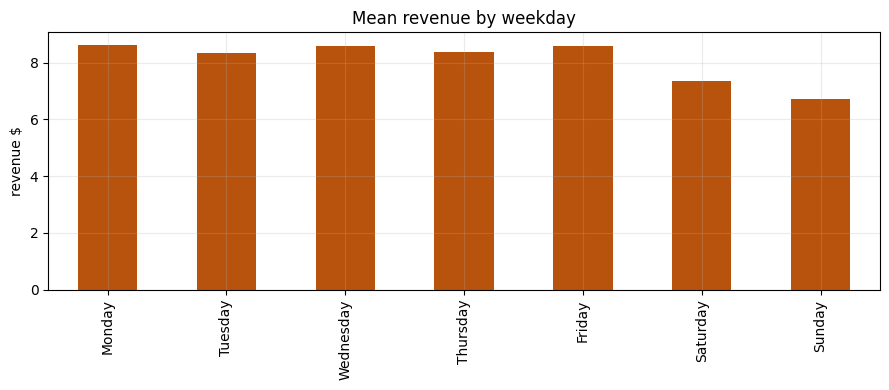

In [3]:
by_dow = ch.assign(dow=ch.date.dt.day_name()).groupby("dow").revenue.mean()
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
by_dow = by_dow.reindex(order)
ax = by_dow.plot(kind="bar", color=ACCENT)
ax.set(title="Mean revenue by weekday", ylabel="revenue $", xlabel="")
plt.tight_layout(); plt.show()

## 3. Category economics — views ≠ money

The core thesis of the product: the videos that get **views** are not the videos
that make **money**. RPM (revenue per 1,000 views) varies sharply by category.

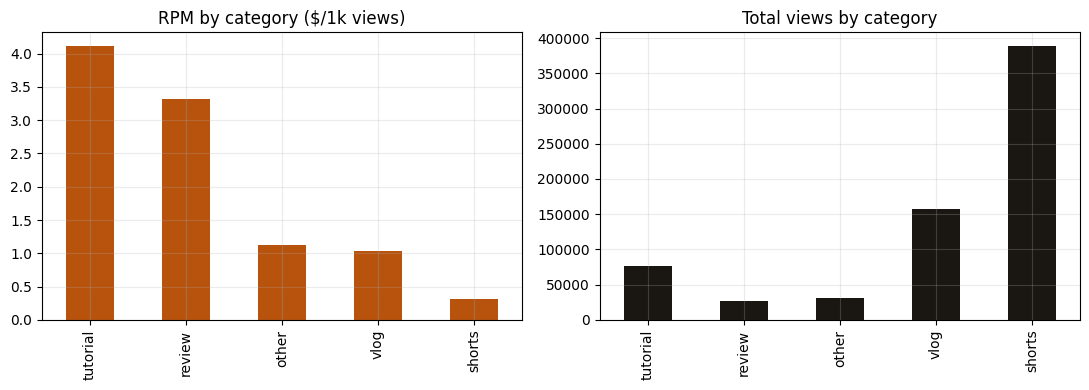

,revenue,views,n,rpm
category,,,,
tutorial,315.02,76572,14,4.11
review,91.09,27513,4,3.31
other,35.38,31262,5,1.13
vlog,163.52,157388,18,1.04
shorts,122.38,388743,9,0.31


In [4]:
cat = (daily.groupby("category")
       .agg(revenue=("revenue_usd", "sum"), views=("views", "sum"), n=("video_id", "nunique")))
cat["rpm"] = cat.revenue / cat.views * 1000
cat = cat.sort_values("rpm", ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
cat.rpm.plot(kind="bar", color=ACCENT, ax=axes[0], title="RPM by category ($/1k views)")
cat.views.plot(kind="bar", color=INK, ax=axes[1], title="Total views by category")
for a in axes: a.set_xlabel("")
plt.tight_layout(); plt.show()
cat.round(2)

Note the inversion: **shorts/vlogs pull the most views but the lowest RPM**,
while **tutorials earn the highest RPM** despite fewer views. A creator
optimising for views would make exactly the wrong thing — which is what the
uplift recommender quantifies.

## 4. The audience-mix shift

`country_top` stores each day's viewer geography. Computing the views-weighted
US and India shares per day reveals a clean step change near day 60 — the US
(high-CPM) audience is replaced by India (lower-CPM), which is what pushes
revenue down in chart 1.

C:\Users\aaqui\AppData\Local\Temp\claude\ipykernel_11596\3776491750.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  geo = daily.groupby("date").apply(


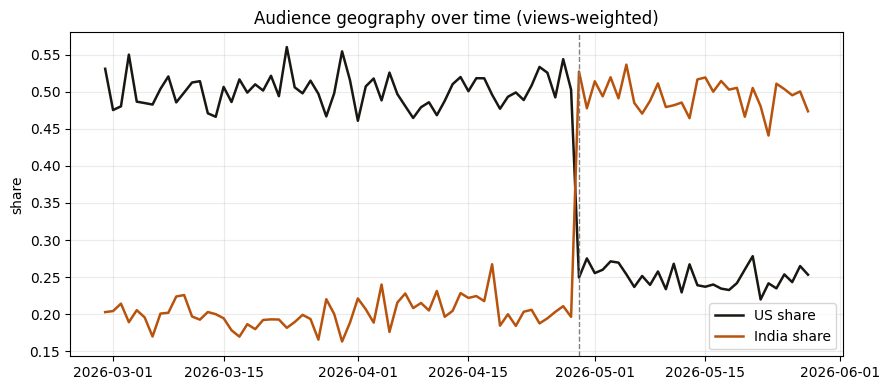

In [5]:
def geo_share(row, cc):
    if not isinstance(row, str) or not row:
        return np.nan
    return json.loads(row).get(cc, 0.0)

for cc in ("US", "IN"):
    daily[f"share_{cc}"] = daily.country_top.apply(lambda r: geo_share(r, cc))

geo = daily.groupby("date").apply(
    lambda g: pd.Series({
        "US": np.average(g["share_US"].fillna(0), weights=g["views"]),
        "IN": np.average(g["share_IN"].fillna(0), weights=g["views"]),
    })
).reset_index()

fig, ax = plt.subplots()
ax.plot(geo.date, geo.US, color=INK, lw=1.8, label="US share")
ax.plot(geo.date, geo.IN, color=ACCENT, lw=1.8, label="India share")
ax.axvline(ch.date.iloc[60], color="grey", ls="--", lw=1)
ax.set(title="Audience geography over time (views-weighted)", ylabel="share", xlabel="")
ax.legend()
plt.tight_layout(); plt.show()

## Takeaways for the models
- **Weekly seasonality + a level shift** → forecast with a *damped* seasonal
  model, and detect the shift as a changepoint (notebooks 02, 03).
- **RPM varies ~10× by category** and is inversely related to views → the
  recommender must reason about revenue, not views (notebook 04).
- **The day-60 geography swap is the root cause** of the revenue decline → the
  anomaly explainer should attribute it via the country distribution, not CPM.